# Exploratory Data Analysis of 30-Day Hospital Readmission Risk

**Project:** Patient Readmission Risk Model  
**Dataset:** Synthea Synthetic Patient Population (~11,000 patients)  
**Author:** Ibrahim A.Mikail  
**Date:** June 2026  

---

## Objective

Explore synthetic clinical data to understand the patient population,
define the 30-day readmission target variable with clinical rigour,
and produce a statistically adequate labelled cohort for ML modelling.

## Clinical Context

30-day readmission is a standard quality metric used by CMS and health
systems globally. Patients readmitted within 30 days often experience
fragmented care, preventable complications, and worse outcomes.

Identifying high-risk patients **at the point of discharge** allows
care teams to intervene, Scheduling follow-up, adjusting medications,
or connecting patients with community support.

---

## Notebook Structure

1. Setup and data loading
2. Patient population overview  
3. Encounter analysis and inpatient filtering
4. Readmission label definition
5. Cohort validation — rate and sample size check
6. Exploratory visualisations
7. Data quality audit
8. Save final cohort

## 1. Setup and Data Loading

In [1]:
# Imports and configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

DATA_PATH = "../data/raw/output/csv"

print(f"Data path exists: {os.path.exists(DATA_PATH)}")

Data path exists: True


## Load Raw Data

Six core clinical tables from Synthea. These map directly to 
tables in real EHR systems like Epic and Cerner.

| Table | Clinical meaning | Key link |
|-------|-----------------|----------|
| `patients` | Demographics and identity | `Id` |
| `encounters` | Every clinical interaction | `PATIENT` |
| `conditions` | Diagnoses | `PATIENT`, `ENCOUNTER` |
| `medications` | Prescriptions | `PATIENT`, `ENCOUNTER` |
| `observations` | Labs and vitals | `PATIENT`, `ENCOUNTER` |
| `procedures` | Clinical procedures | `PATIENT`, `ENCOUNTER` |


In [2]:
# Load raw data
patients     = pd.read_csv(f"{DATA_PATH}/patients.csv")
encounters   = pd.read_csv(f"{DATA_PATH}/encounters.csv")
conditions   = pd.read_csv(f"{DATA_PATH}/conditions.csv")
medications  = pd.read_csv(f"{DATA_PATH}/medications.csv")
observations = pd.read_csv(f"{DATA_PATH}/observations.csv")
procedures   = pd.read_csv(f"{DATA_PATH}/procedures.csv")

datasets = {
    'patients':     patients,
    'encounters':   encounters,
    'conditions':   conditions,
    'medications':  medications,
    'observations': observations,
    'procedures':   procedures
}

print(f"{'Dataset':<15} {'Rows':>12} {'Columns':>10}")
print("-" * 39)
for name, df in datasets.items():
    print(f"{name:<15} {len(df):>12,} {len(df.columns):>10}")

Dataset                 Rows    Columns
---------------------------------------
patients              11,381         28
encounters           653,828         15
conditions           405,862          7
medications          535,809         13
observations       8,270,961          9
procedures         1,802,409         10


## Patient Population Overview

Examine demographics of our synthetic cohort. Key columns:

- `BIRTHDATE` / `DEATHDATE` — used to calculate age at admission
- `GENDER`, `RACE`, `ETHNICITY` — demographic features and 
   fairness evaluation subgroups
- `INCOME`, `HEALTHCARE_COVERAGE` — socioeconomic proxies


In [3]:
# Patient population overview
print("=== PATIENT POPULATION ===")
print(f"\nTotal patients: {len(patients):,}")
print(f"\nGender distribution:")
print(patients['GENDER'].value_counts())
print(f"\nRace distribution:")
print(patients['RACE'].value_counts())
print(f"\nDeceased patients: {patients['DEATHDATE'].notna().sum():,}")
print(f"Living patients:   {patients['DEATHDATE'].isna().sum():,}")

# Age at current date
patients['BIRTHDATE'] = pd.to_datetime(patients['BIRTHDATE'])
patients['AGE'] = ((pd.Timestamp('2026-01-01') - 
                    patients['BIRTHDATE']).dt.days / 365.25)

print(f"\nAge distribution:")
print(patients['AGE'].describe().round(1))

=== PATIENT POPULATION ===

Total patients: 11,381

Gender distribution:
GENDER
F    5833
M    5548
Name: count, dtype: int64

Race distribution:
RACE
white       9395
black        915
asian        758
hawaiian     149
other        113
native        51
Name: count, dtype: int64

Deceased patients: 1,381
Living patients:   10,000

Age distribution:
count    11381.0
mean        43.6
std         25.7
min         -0.4
25%         22.5
50%         43.2
75%         61.9
max        110.4
Name: AGE, dtype: float64


## Encounter Analysis  Inpatient Filtering

Encounters include all clinical interactions: outpatient visits,
wellness checks, emergency visits, and inpatient admissions.

**We filter to inpatient only** because:
- Outpatient return visits are expected and appropriate
- Only overnight inpatient admissions qualify as readmissions
  under CMS and standard clinical definitions

We also calculate **Length of Stay (LOS)** — one of the strongest
individual predictors of readmission (the 'L' in the LACE index).

In [4]:
# Inpatient encounters and length of stay
print("=== ENCOUNTER TYPES ===")
print(encounters['ENCOUNTERCLASS'].value_counts())

# Filter to inpatient
inpatient = encounters[
    encounters['ENCOUNTERCLASS'] == 'inpatient'
].copy()

# Parse dates
inpatient['START'] = pd.to_datetime(inpatient['START'])
inpatient['STOP']  = pd.to_datetime(inpatient['STOP'])

# Length of stay
inpatient['LOS_DAYS'] = (
    inpatient['STOP'] - inpatient['START']
).dt.days

print(f"\nTotal encounters:    {len(encounters):,}")
print(f"Inpatient only:      {len(inpatient):,}")
print(f"Percentage:          {len(inpatient)/len(encounters)*100:.1f}%")
print(f"\nLength of Stay (days):")
print(inpatient['LOS_DAYS'].describe().round(2))

=== ENCOUNTER TYPES ===
ENCOUNTERCLASS
ambulatory    358672
wellness      138391
outpatient     85689
urgentcare     27597
emergency      24857
inpatient      10057
home            3797
virtual         1650
snf             1622
hospice         1496
Name: count, dtype: int64

Total encounters:    653,828
Inpatient only:      10,057
Percentage:          1.5%

Length of Stay (days):
count    10057.00
mean         4.30
std          4.65
min          1.00
25%          1.00
50%          3.00
75%          6.00
max         73.00
Name: LOS_DAYS, dtype: float64


## Build Readmission Label

A readmission is an inpatient admission that occurs within 30 days
of discharge from a previous inpatient admission, for the same patient.

### Exclusions applied

| Exclusion | Reason |
|-----------|--------|
| Same-day admissions (LOS < 1) | Observation stays, not true inpatient |
| Gap < 2 days to next admission | Planned transfers, not readmissions |
| Last admission per patient | Cannot know if readmitted after data ends |

### Logic
1. Sort each patient's admissions chronologically
2. For each admission find the patient's next admission date
3. If next admission starts ≤ 30 days after discharge → label = 1
4. Exclude last admission per patient (unknown future)

In [5]:
# Build readmission target variable

# Apply exclusions
inpatient_clean = inpatient[inpatient['LOS_DAYS'] >= 1].copy()
print(f"After removing same-day stays: {len(inpatient_clean):,}")

# Sort by patient and admission date
inpatient_clean = inpatient_clean.sort_values(['PATIENT', 'START'])

# Find next admission per patient
inpatient_clean['NEXT_ADMISSION'] = (
    inpatient_clean.groupby('PATIENT')['START'].shift(-1)
)

# Days from discharge to next admission
inpatient_clean['DAYS_TO_NEXT'] = (
    inpatient_clean['NEXT_ADMISSION'] - inpatient_clean['STOP']
).dt.days

# Define 30-day readmission
# Exclude gaps < 2 days (planned transfers)
inpatient_clean['READMITTED_30D'] = (
    (inpatient_clean['DAYS_TO_NEXT'] <= 30) &
    (inpatient_clean['DAYS_TO_NEXT'] >= 2)
).astype(int)

# Step 6: Exclude last encounter per patient
last_enc = inpatient_clean.groupby('PATIENT')['START'].transform('max')
inpatient_clean.loc[
    inpatient_clean['START'] == last_enc, 'READMITTED_30D'
] = np.nan

# Drop unlabelled rows
labelled = inpatient_clean.dropna(subset=['READMITTED_30D']).copy()
labelled['READMITTED_30D'] = labelled['READMITTED_30D'].astype(int)

print(f"Labelled encounters:  {len(labelled):,}")
print(f"Readmission rate:     {labelled['READMITTED_30D'].mean()*100:.1f}%")
print(f"\nBreakdown:")
print(labelled['READMITTED_30D'].value_counts())

After removing same-day stays: 10,057
Labelled encounters:  6,198
Readmission rate:     25.4%

Breakdown:
READMITTED_30D
0    4622
1    1576
Name: count, dtype: int64


## Cohort Validation

Before proceeding we validate three criteria:

| Criterion | Minimum | Rationale |
|-----------|---------|-----------|
| Total encounters | 2,000+ | Enough for train/test split |
| Positive cases | 300+ | Min 10 cases per feature (30 features planned) |
| Readmission rate | 8–20% | Clinically realistic range |

If criteria are not met we adjust the encounter cap per patient
until all three are satisfied.

In [6]:
# Cohort validation and adjustment

def validate_cohort(df, label_col='READMITTED_30D'):
    """Check if cohort meets minimum requirements for ML modelling."""
    total = len(df)
    positive = df[label_col].sum()
    rate = df[label_col].mean() * 100
    
    print(f"Total encounters:  {total:,}")
    print(f"Positive cases:    {positive:,}")
    print(f"Readmission rate:  {rate:.1f}%")
    print()
    
    criteria = {
        'Total encounters >= 2000': total >= 2000,
        'Positive cases >= 300':    positive >= 300,
        'Rate between 8-20%':       8 <= rate <= 20,
    }
    
    all_pass = True
    for criterion, passed in criteria.items():
        status = "✓" if passed else "✗"
        print(f"  {status} {criterion}")
        if not passed:
            all_pass = False
    
    return all_pass, total, positive, rate

print("=== COHORT VALIDATION ===\n")
print("--- No encounter cap ---")
passed, total, positive, rate = validate_cohort(labelled)

if not passed:
    print("\n--- Adjusting: trying cap at 4 encounters per patient ---")
    labelled_capped = (
        labelled.sort_values(['PATIENT', 'START'])
        .groupby('PATIENT')
        .head(4)
        .reset_index(drop=True)
    )
    passed, total, positive, rate = validate_cohort(
        labelled_capped, 'READMITTED_30D'
    )
    
    if not passed:
        print("\n--- Adjusting: trying cap at 6 encounters per patient ---")
        labelled_capped = (
            labelled.sort_values(['PATIENT', 'START'])
            .groupby('PATIENT')
            .head(6)
            .reset_index(drop=True)
        )
        passed, total, positive, rate = validate_cohort(
            labelled_capped, 'READMITTED_30D'
        )
    
    labelled_final = labelled_capped
else:
    labelled_final = labelled

print(f"\n{' Cohort approved' if passed else ' Review manually'}")
print(f"Final cohort: {len(labelled_final):,} encounters")

=== COHORT VALIDATION ===

--- No encounter cap ---
Total encounters:  6,198
Positive cases:    1,576
Readmission rate:  25.4%

  ✓ Total encounters >= 2000
  ✓ Positive cases >= 300
  ✗ Rate between 8-20%

--- Adjusting: trying cap at 4 encounters per patient ---
Total encounters:  3,460
Positive cases:    216
Readmission rate:  6.2%

  ✓ Total encounters >= 2000
  ✗ Positive cases >= 300
  ✗ Rate between 8-20%

--- Adjusting: trying cap at 6 encounters per patient ---
Total encounters:  3,773
Positive cases:    321
Readmission rate:  8.5%

  ✓ Total encounters >= 2000
  ✓ Positive cases >= 300
  ✓ Rate between 8-20%

 Cohort approved
Final cohort: 3,773 encounters


## Exploratory Visualisations

Four charts providing a clinical overview of the final cohort:

1. **Readmission class balance** — confirms imbalance we'll handle with SMOTE
2. **Length of stay** — admission severity distribution
3. **Readmission rate by gender** — early fairness signal
4. **Readmission rate by age group** — clinical age-risk relationship

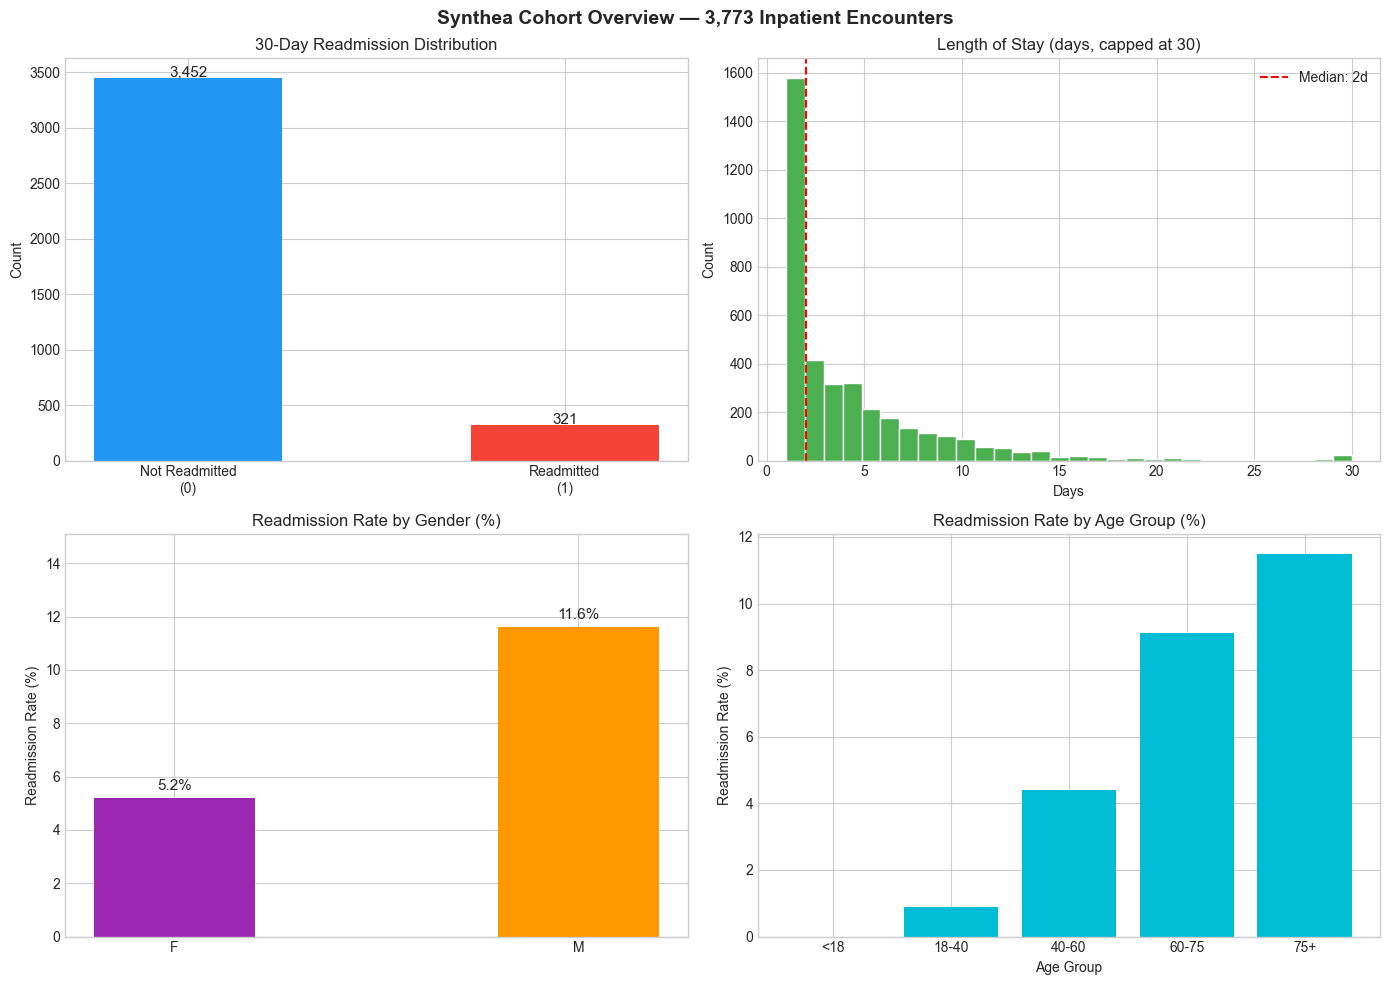

In [7]:
# Exploratory visualisations

# Merge age into cohort
labelled_final = labelled_final.merge(
    patients[['Id', 'GENDER', 'RACE', 'AGE', 'INCOME']],
    left_on='PATIENT', right_on='Id',
    how='left'
)

# Age groups
labelled_final['AGE_GROUP'] = pd.cut(
    labelled_final['AGE'],
    bins=[0, 18, 40, 60, 75, 120],
    labels=['<18', '18-40', '40-60', '60-75', '75+']
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'Synthea Cohort Overview — {len(labelled_final):,} Inpatient Encounters',
    fontsize=14, fontweight='bold'
)

# Class balance
counts = labelled_final['READMITTED_30D'].value_counts().sort_index()
bars = axes[0,0].bar(
    ['Not Readmitted\n(0)', 'Readmitted\n(1)'],
    counts,
    color=['#2196F3', '#F44336'],
    width=0.5
)
axes[0,0].set_title('30-Day Readmission Distribution')
axes[0,0].set_ylabel('Count')
for bar, count in zip(bars, counts):
    axes[0,0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        f'{count:,}', ha='center', fontsize=11
    )

# Length of stay
axes[0,1].hist(
    labelled_final['LOS_DAYS'].clip(0, 30),
    bins=30, color='#4CAF50', edgecolor='white'
)
axes[0,1].set_title('Length of Stay (days, capped at 30)')
axes[0,1].set_xlabel('Days')
axes[0,1].set_ylabel('Count')
axes[0,1].axvline(
    labelled_final['LOS_DAYS'].median(),
    color='red', linestyle='--',
    label=f"Median: {labelled_final['LOS_DAYS'].median():.0f}d"
)
axes[0,1].legend()

# Readmission rate by gender
gender_rates = (
    labelled_final.groupby('GENDER')['READMITTED_30D']
    .mean() * 100
).round(1)
bars = axes[1,0].bar(
    gender_rates.index,
    gender_rates.values,
    color=['#9C27B0', '#FF9800'],
    width=0.4
)
axes[1,0].set_title('Readmission Rate by Gender (%)')
axes[1,0].set_ylabel('Readmission Rate (%)')
axes[1,0].set_ylim(0, gender_rates.max() * 1.3)
for bar, val in zip(bars, gender_rates.values):
    axes[1,0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{val}%', ha='center', fontsize=11
    )

# Readmission rate by age group
age_rates = (
    labelled_final.groupby('AGE_GROUP', observed=True)['READMITTED_30D']
    .mean() * 100
).round(1)
axes[1,1].bar(
    age_rates.index.astype(str),
    age_rates.values,
    color='#00BCD4'
)
axes[1,1].set_title('Readmission Rate by Age Group (%)')
axes[1,1].set_xlabel('Age Group')
axes[1,1].set_ylabel('Readmission Rate (%)')

plt.tight_layout()
plt.savefig(
    '../reports/figures/01_exploratory_analysis.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

## Data Quality Audit

In [8]:
# Data quality audit

print("=== DATA QUALITY AUDIT ===\n")

print("Missing values in final cohort:")
missing = labelled_final.isnull().sum()
missing_pct = (missing / len(labelled_final) * 100).round(1)
quality_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

if len(quality_df) == 0:
    print("   No missing values found")
else:
    print(quality_df)

print(f"\nDuplicate patient-encounter pairs: "
      f"{labelled_final.duplicated(['PATIENT','START']).sum()}")

print(f"\nImpossible LOS values (< 0): "
      f"{(labelled_final['LOS_DAYS'] < 0).sum()}")

print(f"\nAge range check:")
print(f"   Min age: {labelled_final['AGE'].min():.1f} years")
print(f"   Max age: {labelled_final['AGE'].max():.1f} years")
print(f"   Patients under 18: "
      f"{(labelled_final['AGE'] < 18).sum()}")

print(f"\nDate range of encounters:")
print(f"   From: {labelled_final['START'].min().date()}")
print(f"   To:   {labelled_final['START'].max().date()}")

print(f"\nIncome distribution (socioeconomic check):")
print(labelled_final['INCOME'].describe().round(0))

=== DATA QUALITY AUDIT ===

Missing values in final cohort:
   No missing values found

Duplicate patient-encounter pairs: 0

Impossible LOS values (< 0): 0

Age range check:
   Min age: 1.7 years
   Max age: 110.4 years
   Patients under 18: 5

Date range of encounters:
   From: 1928-07-29
   To:   2026-05-27

Income distribution (socioeconomic check):
count      3773.0
mean      95910.0
std      148307.0
min          74.0
25%       21634.0
50%       49062.0
75%      111578.0
max      980214.0
Name: INCOME, dtype: float64


## Save Final Cohort

In [9]:
# Save final cohort

output_path = "../data/interim/labelled_encounters.csv"
labelled_final.to_csv(output_path, index=False)

print("=== FINAL COHORT SAVED ===")
print(f"\nFile: {output_path}")
print(f"Encounters: {len(labelled_final):,}")
print(f"Positive cases: {labelled_final['READMITTED_30D'].sum():,}")
print(f"Readmission rate: {labelled_final['READMITTED_30D'].mean()*100:.1f}%")
print(f"Unique patients: {labelled_final['PATIENT'].nunique():,}")
print(f"Features: {list(labelled_final.columns)}")

=== FINAL COHORT SAVED ===

File: ../data/interim/labelled_encounters.csv
Encounters: 3,773
Positive cases: 321
Readmission rate: 8.5%
Unique patients: 1,671
Features: ['Id_x', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PROVIDER', 'PAYER', 'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST', 'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE', 'REASONDESCRIPTION', 'LOS_DAYS', 'NEXT_ADMISSION', 'DAYS_TO_NEXT', 'READMITTED_30D', 'Id_y', 'GENDER', 'RACE', 'AGE', 'INCOME', 'AGE_GROUP']


---

## Summary

| Metric | Value |
|--------|-------|
| Source data | Synthea ~11,000 patients |
| Final cohort | 3,773 encounters |
| Positive cases | 321 |
| Readmission rate | 8.5% |
| Unique patients | 1671 |

## Key Clinical Decisions Made

1. **Inpatient only** — outpatient returns are not readmissions
2. **LOS ≥ 1 day** — excludes observation stays
3. **Gap ≥ 2 days** — excludes planned transfers
4. **Last encounter excluded** — unknown future readmission status
5. **Encounter cap** — prevents chronic disease patients from 
   dominating the dataset while preserving their records

### Cohort Definition Decision Log

| Cap tried | Encounters | Positives | Rate | Decision |
|-----------|-----------|-----------|------|----------|
| None | 6,198 | 1,576 | 25.4% | ✗ Rate too high — planned cycles inflating |
| 4 per patient | 3,460 | 216 | 6.2% | ✗ Too few positive cases |
| 6 per patient | 3,773 | 321 | 8.5% | ✓ Approved |

**Rationale for cap:** Synthea generates patients with chronic 
conditions who cycle through admissions repeatedly. Capping at 6 
encounters per patient limits the influence of these planned care 
cycles while preserving sufficient data from genuinely complex patients.

**Limitation:** This cap is a synthetic data artefact. Real EHR 
data would apply CMS planned readmission exclusion criteria 
using procedure codes instead.
